In [80]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


시나리오별 예상 매출액
  시나리오  금리영향  마케팅영향   예상매출액
0   낙관   1.5      5  1075.0
1   중립   2.5      3   965.0
2   비관   4.0      1   830.0


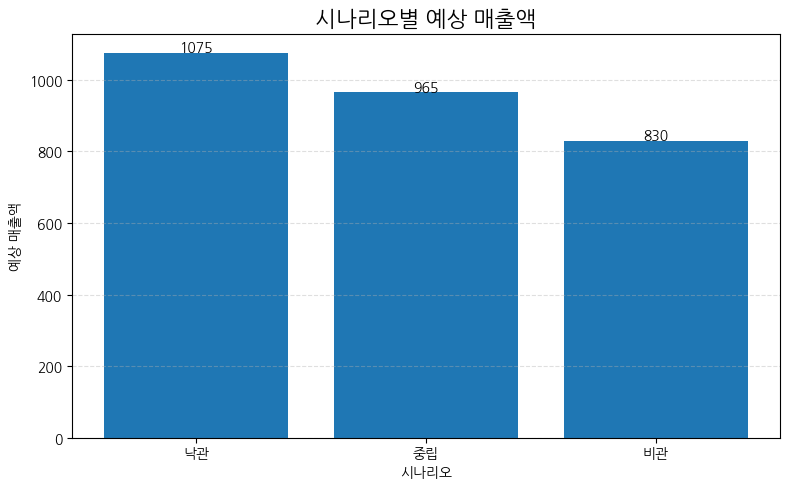

In [87]:
# ============================================================
# 시나리오 기반 매출 시뮬레이션
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 기본 설정
# ============================================================

base_sales = 1000

# ============================================================
# 시나리오 데이터
# ============================================================

scenario = {
    '낙관': {'금리영향': 1.5, '마케팅영향': 5},
    '중립': {'금리영향': 2.5, '마케팅영향': 3},
    '비관': {'금리영향': 4.0, '마케팅영향': 1}
}

# ============================================================
# 매출 계산
# 매출 = 기본매출 - (금리영향×50) + (마케팅영향×30)
# ============================================================

results = []

for name, value in scenario.items():

    sales = (
        base_sales
        - (value['금리영향'] * 50)
        + (value['마케팅영향'] * 30)
    )

    results.append([name,
                    value['금리영향'],
                    value['마케팅영향'],
                    sales])

# ============================================================
# 결과 테이블
# ============================================================

result_df = pd.DataFrame(
    results,
    columns=['시나리오', '금리영향', '마케팅영향', '예상매출액']
)

print("=" * 60)
print("시나리오별 예상 매출액")
print("=" * 60)
print(result_df)
print("=" * 60)

# ============================================================
# 막대 그래프
# ============================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    result_df['시나리오'],
    result_df['예상매출액']
)

# 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f'{height:.0f}',
        ha='center',
        fontweight='bold'
    )

plt.title(
    '시나리오별 예상 매출액',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('시나리오')
plt.ylabel('예상 매출액')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()